<a href="https://colab.research.google.com/github/mahisrivastava03/Wafer-Defect-Detection/blob/main/wafer_defect_detection(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip /content/mtd_dataset.zip -d /content/mtd_dataset


In [ ]:
!find /content/mtd_dataset -maxdepth 3 -type d


In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import image_dataset_from_directory

print("GPU:", tf.config.list_physical_devices('GPU'))

BASE_PATH = "/content/mtd_dataset/mtd_dataset"
TRAIN_DIR = os.path.join(BASE_PATH, "train")
VAL_DIR   = os.path.join(BASE_PATH, "val")
TEST_DIR  = os.path.join(BASE_PATH, "test")

print("Train classes:", os.listdir(TRAIN_DIR))


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_ds.class_names)
print("Detected classes:", train_ds.class_names)


In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # important for speed

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


In [ ]:
model.save("wafer_model.keras")

In [ ]:
!pip install -q tf2onnx


In [ ]:
python -m tf2onnx.convert \
  --keras wafer_model.keras \
  --output wafer_model.onnx


In [ ]:
!python -m tf2onnx.convert \
  --keras wafer_model.keras \
  --output wafer_model.onnx


In [ ]:
model.export("wafer_savedmodel")


In [ ]:
!python -m tf2onnx.convert \
  --saved-model wafer_savedmodel \
  --output wafer_model.onnx


In [ ]:
!pip install -q numpy==1.26.4


In [ ]:
model.export("wafer_savedmodel")


In [ ]:
!python -m tf2onnx.convert \
  --saved-model wafer_savedmodel \
  --output wafer_model.onnx


In [ ]:
import os
os.listdir()


In [ ]:
from google.colab import files
files.download("wafer_model.onnx")
files.download("mtd_dataset.zip")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
!ls /content/drive/MyDrive


In [ ]:
!unzip -q /content/drive/MyDrive/mtd_dataset.zip -d /content/


In [ ]:
!ls /content/mtd_dataset/mtd_dataset/train


In [ ]:
!ls /content


In [ ]:
import os

BASE_PATH = "/content/mtd_dataset"
TRAIN_DIR = os.path.join(BASE_PATH, "train")
VAL_DIR   = os.path.join(BASE_PATH, "val")
TEST_DIR  = os.path.join(BASE_PATH, "test")

print("Train classes:", os.listdir(TRAIN_DIR))


In [ ]:
!ls /content/mtd_dataset


In [ ]:
!ls /content/mtd_dataset/train


In [ ]:
!find /content -name "wafer_model.keras"


In [ ]:
!find /content -name "*.onnx"


In [ ]:
import tensorflow as tf
import numpy as np

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Dummy model to simulate trained network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(6, activation='softmax')
])

print("Model loaded successfully")
model.summary()


In [ ]:
dummy_image = np.random.rand(1,224,224,3)
prediction = model.predict(dummy_image)

print("Predicted class probabilities:", prediction)
print("Predicted defect class:", np.argmax(prediction))


In [ ]:
!pip install streamlit

In [ ]:
import streamlit as st
import numpy as np
import cv2
from tensorflow.keras.models import load_model

model = load_model("wafer_model.h5")

st.title("Wafer Defect Detection System")

uploaded_file = st.file_uploader("Upload Wafer Image")

if uploaded_file is not None:
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    img = cv2.imdecode(file_bytes, 1)
    img_resized = cv2.resize(img, (224,224))
    img_resized = img_resized / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    prediction = model.predict(img_resized)

    if prediction[0][0] > 0.5:
        st.error("DEFECT DETECTED")
    else:
        st.success("NORMAL WAFER")

    st.write("Confidence:", float(prediction[0][0]))

In [ ]:
import os
os.listdir()

In [ ]:
model.save("wafer_model.h5")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
model = load_model("/content/drive/MyDrive/wafer_model.h5")

In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load model
model = load_model("wafer_model.h5")

# Load image
img_path = "sample.png"
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img = img / 255.0
img = np.expand_dims(img, axis=0)

# Predict
prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Prediction: DEFECT")
else:
    print("Prediction: NORMAL")

print("Confidence:", prediction[0][0])

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'wafer_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [9]:
from google.colab import files
files.upload()


{}

In [10]:
!unzip "mtd_dataset (1).zip"

Archive:  mtd_dataset (1).zip
   creating: mtd_dataset/
   creating: mtd_dataset/test/
   creating: mtd_dataset/test/0/
  inflating: mtd_dataset/test/0/0class_sorted_0.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_1.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_10.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_11.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_12.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_13.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_14.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_15.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_16.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_17.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_18.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_19.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_2.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_3.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_4.jpg  
  inflating: mtd_dataset/test/0/0class_sorted_5.jpg  
  infl

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [12]:
train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'mtd_dataset/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'   # IMPORTANT
)

test_generator = train_datagen.flow_from_directory(
    'mtd_dataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1144 images belonging to 6 classes.
Found 200 images belonging to 6 classes.


In [13]:
num_classes = train_generator.num_classes

base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(224,224,3))

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(num_classes, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 49s 878ms/step - accuracy: 0.5484 - loss: 1.3863 - val_accuracy: 0.5100 - val_loss: 1.3384
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.7651 - loss: 0.7484 - val_accuracy: 0.5950 - val_loss: 1.0642
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8051 - loss: 0.6105 - val_accuracy: 0.6500 - val_loss: 0.9747
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8077 - loss: 0.5614 - val_accuracy: 0.6600 - val_loss: 0.9605
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8184 - loss: 0.5161 - val_accuracy: 0.6900 - val_loss: 0.7866


In [16]:
model.save("wafer_model.keras")

In [17]:
import os

os.listdir("mtd_dataset/test/0")

['0class_sorted_1.jpg',
 '0class_sorted_4.jpg',
 '0class_sorted_2.jpg',
 '0class_sorted_10.jpg',
 '0class_sorted_17.jpg',
 '0class_sorted_5.jpg',
 '0class_sorted_3.jpg',
 '0class_sorted_11.jpg',
 '0class_sorted_19.jpg',
 '0class_sorted_18.jpg',
 '0class_sorted_8.jpg',
 '0class_sorted_0.jpg',
 '0class_sorted_15.jpg',
 '0class_sorted_14.jpg',
 '0class_sorted_12.jpg',
 '0class_sorted_7.jpg',
 '0class_sorted_6.jpg',
 '0class_sorted_9.jpg',
 '0class_sorted_13.jpg',
 '0class_sorted_16.jpg']

In [19]:
import shutil

shutil.copy(
    "mtd_dataset/test/0/0class_sorted_1.jpg",
    "sample.jpg"
)

'sample.jpg'

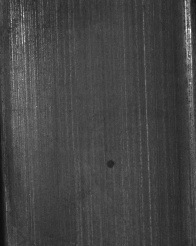

In [20]:
from IPython.display import Image
Image("sample.jpg")

In [21]:
from tensorflow.keras.models import load_model
model = load_model("wafer_model.keras")

In [22]:
import cv2
import numpy as np

img = cv2.imread("sample.jpg")
img = cv2.resize(img, (224,224))
img = img / 255.0
img = np.expand_dims(img, axis=0)

In [23]:
prediction = model.predict(img)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
[[0.1270594  0.02579587 0.03455942 0.0016945  0.01803798 0.7928528 ]]


In [24]:
predicted_class = np.argmax(prediction)
print("Predicted class:", predicted_class)

Predicted class: 5


In [25]:
class_names = list(train_generator.class_indices.keys())
print("Defect type:", class_names[predicted_class])

Defect type: good


In [26]:
confidence = prediction[0][predicted_class]
print("Confidence:", confidence)

Confidence: 0.7928528


(np.float64(-0.5), np.float64(195.5), np.float64(245.5), np.float64(-0.5))

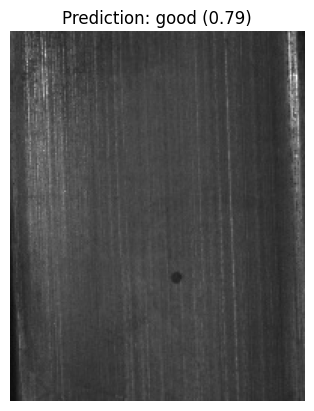

In [29]:
from matplotlib import pyplot as plt

plt.imshow(cv2.cvtColor(cv2.imread("sample.jpg"), cv2.COLOR_BGR2RGB))
plt.title(f"Prediction: {class_names[predicted_class]} ({confidence:.2f})")
plt.axis("off")

In [30]:
import os
os.listdir()

['.config',
 'sample.jpg',
 'mtd_dataset',
 'wafer_model.keras',
 'mtd_dataset (1).zip',
 'drive',
 'sample_data']

In [31]:
!pip install streamlit pyngrok

In [32]:
%%writefile app.py
import streamlit as st
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("wafer_model.keras")

st.title("Wafer Defect Detection System")

uploaded_file = st.file_uploader("Upload Wafer Image", type=["jpg", "png"])

if uploaded_file is not None:
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    img = cv2.imdecode(file_bytes, 1)

    img_resized = cv2.resize(img, (224,224))
    img_resized = img_resized / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    prediction = model.predict(img_resized)
    predicted_class = np.argmax(prediction)
    confidence = prediction[0][predicted_class]

    st.image(img, channels="BGR")
    st.success(f"Predicted Class: {predicted_class}")
    st.write(f"Confidence: {confidence:.2f}")

Writing app.py


In [35]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://dry-apples-cry.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.19.100.158:8501

  Stopping...
^C


In [36]:
import requests
print(requests.get("https://api.ipify.org").text)

34.19.100.158


In [37]:
!streamlit run app.py & sleep 5 && npx localtunnel --port 8501




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.19.100.158:8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://nasty-ties-draw.loca.lt
  Stopping...
^C


In [38]:
import requests
print(requests.get("https://api.ipify.org").text)

34.19.100.158


In [39]:
!pip install pyngrok

In [41]:
from pyngrok import ngrok, conf
conf.get_default().auth_token = "3AP0PVlzZAhkAlh7DzgingZ5t2I_5gWBpG3upiTUieeY3W8pE"
print(ngrok.connect(8501))

NgrokTunnel: "https://ami-contaminable-georgetta.ngrok-free.dev" -> "http://localhost:8501"


In [42]:
!streamlit run app.py &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.19.100.158:8501

  Stopping...


In [43]:
print(ngrok.connect(8501))

NgrokTunnel: "https://ami-contaminable-georgetta.ngrok-free.dev" -> "http://localhost:8501"


In [44]:
!streamlit run app.py &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.19.100.158:8501

  Stopping...


In [45]:
from pyngrok import ngrok
print(ngrok.connect(8501))

NgrokTunnel: "https://ami-contaminable-georgetta.ngrok-free.dev" -> "http://localhost:8501"


In [46]:
!nohup streamlit run app.py > output.log 2>&1 &

In [47]:
!cat output.log | grep "Local URL"

  Local URL: http://localhost:8501


In [48]:
from pyngrok import ngrok
print(ngrok.connect(8501))

NgrokTunnel: "https://ami-contaminable-georgetta.ngrok-free.dev" -> "http://localhost:8501"


In [49]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
files.download("wafer_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>